In [ ]:
import openseespy.opensees as ops
import math
import opsvis as opsv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MultipleLocator,FormatStrFormatter
from openseespy.opensees import *
import time

# 记录开始时间
start_time = time.time()


#####################################  Parameters  ###################################
impact_mass = 0.960 #冲击质量 (tone)
impact_velocity = 4.14 # 冲击速度（m/s） 
P_static = -167.5 * 1000 # 静力荷载(N)
Bcol = 250 # 截面宽度 (mm)
Hcol = 250 # 截面高度 (mm)
c = 25 # 保护层厚度 (mm)
d = 16 # 纵筋直径 (mm)
As = d * d * math.pi # 纵筋总面积 (mm^2)
Ac = 250 *250 - As # 混凝土面积 (mm^2)
Asv = 2 * 10 * 10 * math.pi/4 # 箍筋面积 (mm^2)
Acor = (Bcol - 2*c) * (Hcol - 2*c)

fy = 423 # 纵筋静态强度 (MPa)
fyv = 430 # 箍筋静态强度 (MPa)
fc1 = 28.1 # 预制混凝土强度 (MPa)
fc2 = 34.8 # 现浇混凝土强度 (MPa)

DIF_fc = 1.3
DIF_fy = 1.3
DIF_P = 1.4

fc1_dyn = fc1 * DIF_fc 
fc2_dyn = fc2 * DIF_fc 
fy_dyn = fy * DIF_fy

####################################### 系统设置 #####################################
ops.wipe() # 初始清空 
ops.model('basic', '-ndm', 2, '-ndf', 3)  # frame 2D

####################################### 定义节点 #####################################
ele_mass = 0.015

ops.node(1,  0.0,   0.0,  "-mass", ele_mass/2, ele_mass/2, ele_mass/2)
ops.node(2,  0.0, 100.0,  "-mass", ele_mass, ele_mass, ele_mass)
ops.node(3,  0.0, 200.0,  "-mass", ele_mass, ele_mass, ele_mass)
ops.node(4,  0.0, 300.0,  "-mass", ele_mass/2, ele_mass/2, ele_mass/2)
ops.node(5,  0.0, 400.0,  "-mass", ele_mass, ele_mass, ele_mass)
ops.node(6,  0.0, 500.0,  "-mass", ele_mass, ele_mass, ele_mass)
ops.node(7,  0.0, 600.0,  "-mass", ele_mass, ele_mass, ele_mass)
ops.node(8,  0.0, 700.0,  "-mass", ele_mass, ele_mass, ele_mass)
ops.node(9,  0.0, 800.0,  "-mass", ele_mass, ele_mass, ele_mass)
ops.node(10, 0.0, 900.0,  "-mass", ele_mass, ele_mass, ele_mass,)
ops.node(11, 0.0, 1000.0, "-mass", ele_mass, ele_mass, ele_mass)
ops.node(12, 0.0, 1100.0, "-mass", ele_mass, ele_mass, ele_mass)
ops.node(13, 0.0, 1200.0, "-mass", ele_mass, ele_mass, ele_mass)
ops.node(14, 0.0, 1300.0, "-mass", ele_mass, ele_mass, ele_mass)
ops.node(15, 0.0, 1400.0, "-mass", ele_mass, ele_mass, ele_mass)
ops.node(16, 0.0, 1500.0, "-mass", 0.2075, 0.2075, 0.2075)

ops.node(104, 0.0, 300.0,  "-mass", ele_mass/2, ele_mass/2, ele_mass/2)

ops.node(19, 0.0, 400.0)
ops.node(20, 0.0, 500.0)
ops.node(21, 0.0, 600.0)

ops.node(29, 0.0, 400.0, "-mass", impact_mass/3, 0, 0)
ops.node(30, 0.0, 500.0, "-mass", impact_mass/3, 0, 0)
ops.node(31, 0.0, 600.0, "-mass", impact_mass/3, 0, 0)

ops.equalDOF(4, 104, 2, 3)

ops.equalDOF(30, 31, 1)
ops.equalDOF(30, 29, 1)

###################################### 定义节点约束 ##################################
ops.fix( 1, 1, 1, 1)

ops.fix(19, 0, 1, 1)
ops.fix(20, 0, 1, 1)
ops.fix(21, 0, 1, 1)

ops.fix(29, 0, 1, 1)
ops.fix(30, 0, 1, 1)
ops.fix(31, 0, 1, 1)

####################################### 定义材料 #####################################
def create_steel(IDSteel, fy):
    Fy_Steel = fy
    E0_Steel = 206000
    bs_Steel = 0.026
    R0 = 12.5
    cR1 = 0.925
    cR2 = 0.15
    ops.uniaxialMaterial('Steel02', IDSteel, Fy_Steel, E0_Steel, bs_Steel,R0,cR1,cR2)

def create_concrete(IDcoverC, IDcoreC, fpc):
    # uniaxialMaterial('Concrete01', matTag, fpc, epsc0, fpcu, epsU)
    # uniaxialMaterial（'Concrete04'， matTag， fc， epsc， epscu， Ec， fct， et， beta)
    fpc_cover=-fpc
    epsc0_cover=-0.002
    epsU_cover=-0.004
    Ec_cover = 4730 * math.sqrt(abs(fpc_cover)) 
    fpt_cover = 0.56 * math.sqrt(abs(fpc_cover)) 
    et_cover = 0.0001 * math.sqrt(abs(fpc_cover))
    beta = 0.2
    # ops.uniaxialMaterial('Concrete01', IDcoverC, fpc_cover, epsc0_cover, fpcu_cover, epsU_cover)
    ops.uniaxialMaterial('Concrete04', IDcoverC, fpc_cover, epsc0_cover, epsU_cover, Ec_cover, fpt_cover, et_cover, beta)
    a = 1.0
    fyv_dyn = fyv * DIF_fy
    fpc_core= -(fpc + 2*a*(fyv_dyn * Asv) / Acor)
    epsc0_core=-0.002 * ( 1 + 5 * fpc_core/fpc_cover - 1)
    epsU_core=epsc0_core-0.02
    Ec_core = 4730 * math.sqrt(abs(fpc_core)) 
    fpt_core = 0.56 * math.sqrt(abs(fpc_core)) 
    et_core = 0.0001 * math.sqrt(abs(fpc_core))
    beta = 0.2
    # ops.uniaxialMaterial('Concrete01', IDcoreC, fpc_core, epsc0_core, fpcu_core, epsU_core)
    ops.uniaxialMaterial('Concrete04', IDcoreC, fpc_core, epsc0_core, epsU_core, Ec_core, fpt_core, et_core, beta )

# Material rebar
fy_IDSteel = 1
create_steel(fy_IDSteel, fy_dyn)

# Material precast concrete
fpc1_IDcoverC = 2
fpc1_IDcoreC  = 3
create_concrete(fpc1_IDcoverC, fpc1_IDcoreC, fc1_dyn)

# Material cast in place concrete
fpc2_IDcoverC = 4
fpc2_IDcoreC  = 5
create_concrete(fpc2_IDcoverC, fpc2_IDcoreC, fc2_dyn)

####################################### 定义截面 #####################################
y1col = Hcol/2.0
z1col = Bcol/2.0
y2col = 0.5*(Hcol-2*c)/3.0

nFibZ=2
nFibZc=16
nFib=20
nFibCover, nFibCore = 2, 16
As_bar1 = d * d  *math.pi/4
As_bar2 = 78.5

# ['patch', 'rect', matTag, num_fiberY, num_fiberZ, YI, ZI, YJ, ZJ],
# Section precast 
fiber1=1
ops.section('Fiber', fiber1)
ops.patch('rect', fpc1_IDcoreC, nFibCore, nFibZc, c-y1col, c-z1col, y1col-c, z1col-c)
ops.patch('rect', fpc1_IDcoverC, nFib, nFibZ, -y1col, -z1col, y1col, c-z1col)
ops.patch('rect', fpc1_IDcoverC, nFib, nFibZ, -y1col, z1col-c, y1col, z1col)
ops.patch('rect', fpc1_IDcoverC, nFibCover, nFibZc, -y1col, c-z1col, c-y1col, z1col-c)
ops.patch('rect', fpc1_IDcoverC, nFibCover, nFibZc, y1col-c, c-z1col, y1col, z1col-c)
ops.layer('straight', fy_IDSteel, 2, As_bar1, y1col-c, z1col-c, y1col-c, c-z1col)
ops.layer('straight', fy_IDSteel, 2, As_bar1, c-y1col, z1col-c, c-y1col, c-z1col)

# Section cast in place
fiber2=2
ops.section('Fiber', fiber2)
ops.patch('rect', fpc2_IDcoreC, nFibCore, nFibZc, c-y1col, c-z1col, y1col-c, z1col-c)
ops.patch('rect', fpc2_IDcoverC, nFib, nFibZ, -y1col, -z1col, y1col, c-z1col)
ops.patch('rect', fpc2_IDcoverC, nFib, nFibZ, -y1col, z1col-c, y1col, z1col)
ops.patch('rect', fpc2_IDcoverC, nFibCover, nFibZc, -y1col, c-z1col, c-y1col, z1col-c)
ops.patch('rect', fpc2_IDcoverC, nFibCover, nFibZc, y1col-c, c-z1col, y1col, z1col-c)
ops.layer('straight', fy_IDSteel, 2, As_bar1, y1col-c, z1col-c, y1col-c, c-z1col)
ops.layer('straight', fy_IDSteel, 2, As_bar1, c-y1col, z1col-c, c-y1col, c-z1col)

####################################### 定义单元 #####################################
ColtransfTag = 1
integrationTag = 2
integtype = "Legendre"
ops.geomTransf('Linear', ColtransfTag)
ops.beamIntegration(integtype, 1, 1, 2)


"""
Create a HingeMidpoint beamIntegration object. 
Midpoint integration over each hinge region 
is the most accurate one-point integration rule; 
however,it does not place integration points at the element ends 
and there is a small integration error for linear curvature distributions 
along the element.

tag  |int|: tag of the beam integration.
secI |int|: A previous-defined section object for hinge at I.
lpI float: The plastic hinge length at I.
secJ |int|:A previous-defined section object for hinge at J.
lpJ float: The plastic hinge length at J.
secE |int|:A previous-defined section object for the element interio
"""
# element('forceBeamColumn', eleTag, *eleNodes, transfTag, integrationTag, '-iter', maxIter=10, tol=1e-12, '-mass', mass=0.0)
# beamIntegration('HingeRadau', tag, secI, lpI, secJ, lpJ, secE)

ops.element('forceBeamColumn', 1,  1,  2,  1, 1, 'HingeRadau', 1, 0, 1, 0, 2)
ops.element('forceBeamColumn', 2,  2,  3,  1, 1, 'HingeRadau', 1, 0, 1, 0, 2)
ops.element('forceBeamColumn', 3,  3,  4,  1, 1, 'HingeRadau', 1, 0, 1, 0, 2)

ops.element('forceBeamColumn', 4,  104,  5,  1, 1, 'HingeRadau', 1, 0, 1, 0, 1)
ops.element('forceBeamColumn', 5,  5,  6,  1, 1, 'HingeRadau', 1, 0, 1, 0, 1)
ops.element('forceBeamColumn', 6,  6,  7,  1, 1, 'HingeRadau', 1, 0, 1, 0, 1)
ops.element('forceBeamColumn', 7,  7,  8,  1, 1, 'HingeRadau', 1, 0, 1, 0, 1)
ops.element('forceBeamColumn', 8,  8,  9,  1, 1, 'HingeRadau', 1, 0, 1, 0, 1)
ops.element('forceBeamColumn', 9,  9,  10, 1, 1, 'HingeRadau', 1, 0, 1, 0, 1)
ops.element('forceBeamColumn', 10, 10, 11, 1, 1, 'HingeRadau', 1, 0, 1, 0, 1)
ops.element('forceBeamColumn', 11, 11, 12, 1, 1, 'HingeRadau', 1, 0, 1, 0, 1)
ops.element('forceBeamColumn', 12, 12, 13, 1, 1, 'HingeRadau', 1, 0, 1, 0, 1)
ops.element('forceBeamColumn', 13, 13, 14, 1, 1, 'HingeRadau', 1, 0, 1, 0, 1)
ops.element('forceBeamColumn', 14, 14, 15, 1, 1, 'HingeRadau', 1, 0, 1, 0, 1)
ops.element('forceBeamColumn', 15, 15, 16, 1, 1, 'HingeRadau', 1, 0, 1, 0, 1)

####################################### 定义滑移模型 ##################################
P_dyn = - P_static * DIF_P
uu = 1.0
Vk = P_dyn * uu 
Vc = 0.45 * Ac * 0.3 * math.pow(fc1_dyn, 2/3)
Vs = 0.3 * uu * As * fy_dyn
Vd = 0.5 * As * math.sqrt(fc1_dyn * fy_dyn)
Vmax = Vk+Vc+Vs+Vd
Vplateau = Vk+Vs+Vd
print(Vmax, Vplateau)

slipshear_matTag = 66

fp1, sp1 = Vmax, 0.2
fp2, sp2 = Vmax, 2.5
fp3, sp3 = Vplateau, 8.0
fn1, sn1 = -fp1, -sp1
fn2, sn2 = -fp2, -sp2
fn3, sn3 = -fp3, -sp3

print(fp1, sp1, fp2, sp2, fp3, sp3, fn1, sn1, fn2, sn2, fn3, sn3)

# uniaxialMaterial('Hysteretic', matTag, *p1, *p2, *p3=p2, *n1, *n2, *n3=n2, pinchX, pinchY, damage1, damage2, beta=0.0)
ops.uniaxialMaterial('Hysteretic', slipshear_matTag, 
                     fp1, sp1, fp2, sp2, fp3, sp3,
                     fn1, sn1, fn2, sn2, fn3, sn3,
                     1.0, 1.0,
                     0.0, 0.0,
                     0.0)

ops.element("zeroLength", 36, 4, 104, "-mat", slipshear_matTag, "-dir", 1)

####################################### 定义接触模型 ##################################
# element('zeroLength', eleTag, *eleNodes, '-mat', *matTags, '-dir', *dirs)
# uniaxialMaterial('Elastic', matTag, E, eta=0.0, Eneg=E)
# uniaxialMaterial('ElasticPPGap', matTag, E, Fy, gap, eta=0.0, damage='noDamage')
# uniaxialMaterial('ViscousDamper', matTag, K_el, Cd, alpha)
# uniaxialMaterial('Viscous', matTag, C, alpha)
ops.uniaxialMaterial("Elastic", 7, 1.2e5)
ops.uniaxialMaterial('Viscous', 8, 1e5, 1.0)
ops.uniaxialMaterial("ElasticPPGap", 9, 1e6, 1e20, 12)

ops.element("zeroLength", 210, 5, 19, "-mat", 7, "-dir", 1)
ops.element("zeroLength", 211, 6, 20, "-mat", 7, "-dir", 1)
ops.element("zeroLength", 212, 7, 21, "-mat", 7, "-dir", 1)

ops.element("zeroLength", 995, 5, 19, "-mat", 8, "-dir", 1)
ops.element("zeroLength", 996, 6, 20, "-mat", 8, "-dir", 1)
ops.element("zeroLength", 997, 7, 21, "-mat", 8, "-dir", 1)

ops.element("zeroLength", 984, 19, 29, "-mat", 9, "-dir", 1)
ops.element("zeroLength", 985, 20, 30, "-mat", 9, "-dir", 1)
ops.element("zeroLength", 986, 21, 31, "-mat", 9, "-dir", 1)

####################################### 施加轴压荷载 ##################################
# 定义静力荷载的时间序列和模式
ops.timeSeries("Constant", 100)
ops.pattern("Plain", 1, 100)
ops.load(16, 0, P_static, 0)  # 节点16的Y方向荷载

# 进行静力分析

ops.system("BandGeneral")
ops.numberer("Plain")
ops.constraints("Plain")
ops.test("EnergyIncr", 1.0e-8, 500)
ops.algorithm("Newton")
ops.integrator("LoadControl", 1.0)
ops.analysis("Static")
ops.analyze(1)

print("Static analysis completed.")

# 保持荷载并重置时间
ops.loadConst('-time', 0.0)

####################################### 定义检测数据 ####################################
ops.recorder('Node', '-file', './Column/node_disp.txt','-time', '-node', *range(1,17), '-dof', 1, 'disp')
ops.recorder('Node', '-file', './Column/node_104.txt','-time', '-node', 104, '-dof', 1, 'disp')

####################################### 定义冲击荷载 ####################################
Mt = impact_mass * 1000/3   # 冲击质量 (kg)
V0 = impact_velocity      # 冲击速度 (m/s)
ts = 0.0001 # 冲击力持续时间 (s)
P = 4 * Mt * V0 / ts # 冲击力 (N)

# 定义时间序列（矩形脉冲：0~0.001s为P，之后为0）
ops.timeSeries("Path", 101, "-time", 0.0, ts, "-values", P, 0)
# 创建荷载模式（与时间序列关联）
ops.pattern("Plain", 2, 101)
# 在节点21的x方向（自由度1）施加荷载
ops.load(29, 1, 0, 0)  # 格式：节点, Fx, Fy, Fz
ops.load(30, 1, 0, 0)  # 格式：节点, Fx, Fy, Fz
ops.load(31, 1, 0, 0)  # 格式：节点, Fx, Fy, Fz


ops.system("BandGeneral")
ops.numberer("Plain")
ops.constraints("Plain")
ops.test("EnergyIncr", 1.0e-8, 500)
ops.algorithm("Newton")
ops.analysis("Transient")
ops.integrator("Newmark", 0.5, 0.25)
ops.analyze(20000, 0.00005)

print("Dynamic 1 analysis completed.")


ops.wipe()


515867.47970297205 424170.40508023335
515867.47970297205 0.2 515867.47970297205 2.5 424170.40508023335 8.0 -515867.47970297205 -0.2 -515867.47970297205 -2.5 -424170.40508023335 -8.0
Static analysis completed.
Dynamic 1 analysis completed.


WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 48
WARNING NewtonRaphson::solveCurrentStep() -the LinearSysOfEqn failed in solve()
StaticAnalysis::analyze() - the Algorithm failed at iteration: 0 with domain at load factor 1
OpenSees > analyze failed, returned: -3 error flag
WARNING can't set handler after analysis is created
WARNING analysis Transient - no Integrator specified, 
 TransientIntegrator default will be used
after: 500 iterations
 current EnergyIncr: 1.18191e+08 (max: 1e-08) 	Norm deltaX: 0.313676, Norm deltaR: 8.71356e+08
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
DirectIntegrationAnalysis::analyze() - the Algorithm failed at time 0.9949
OpenSees > analyze failed, returned: -3 error flag


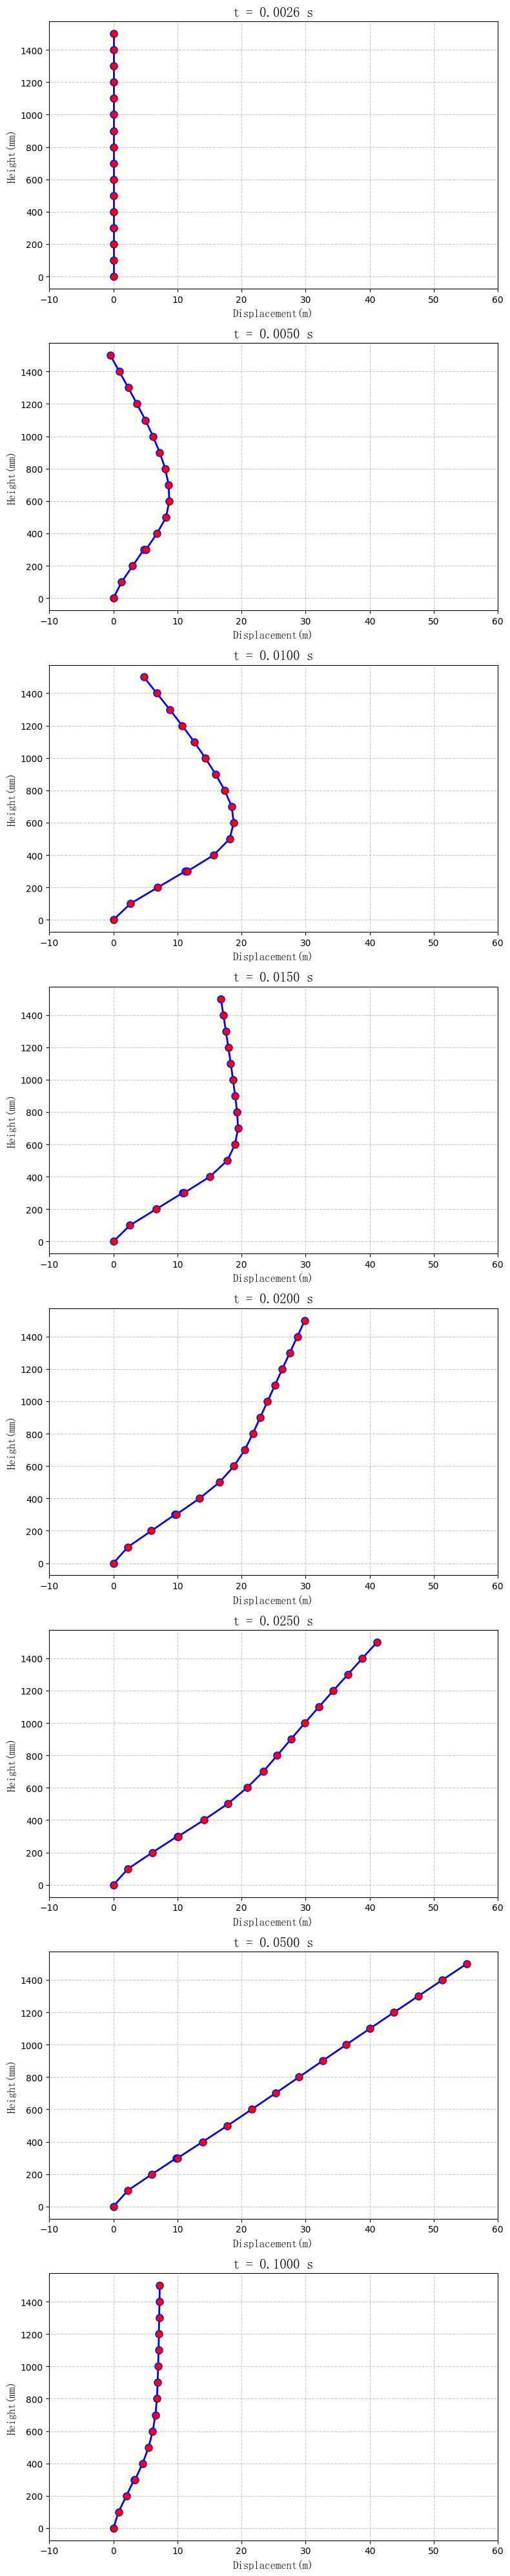

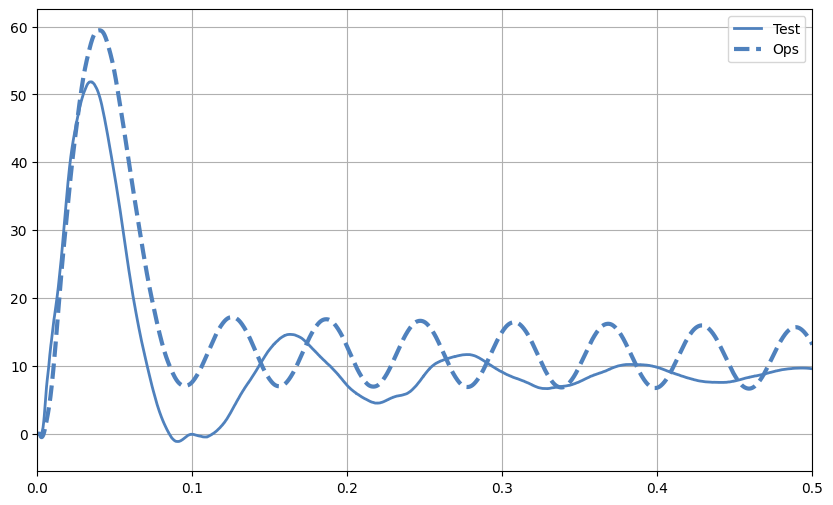

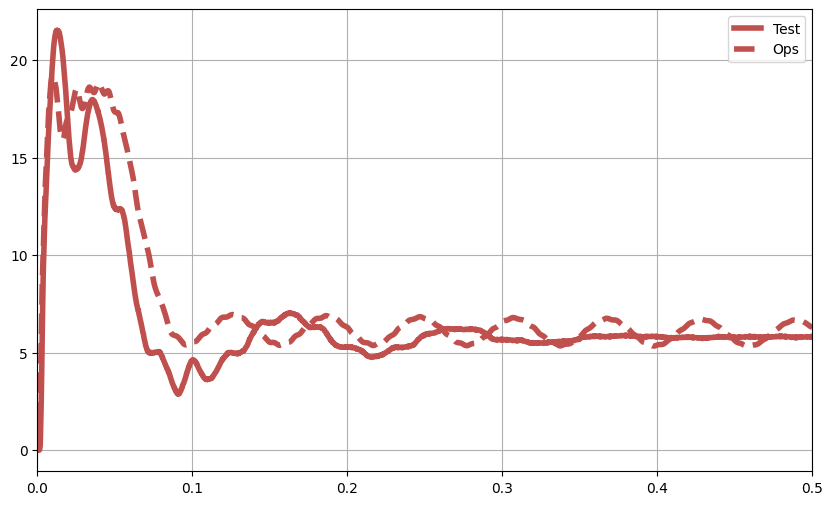

In [5]:
####################################### 绘制图表 #########################################
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt

# 读取数据，假设使用逗号分隔符，且没有标题行
data_i1 = np.loadtxt('./Column/node_disp.txt')  # 使用逗号作为分隔符
data_i1_inter = np.loadtxt('./Column/node_104.txt')    # 节点104的位移

# 解析数据格式（时间列 + 16个节点位移）
time_steps = data_i1[:, 0]      # 时间序列
disp_matrix = data_i1[:, 1:17]  # 节点1-16位移矩阵
disp_104 = data_i1_inter[:, 1]  # 节点104位移

# 获取节点高度坐标（根据原始节点定义，假设为毫米单位）
node_Y = [0, 100, 200, 300, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500]

# 选择多个时间点的索引（例如，假设选取3个特征时刻）
selected_indices = [50, 100, 200, 300, 400, 500, 1000, 1999]  # 选取的时间步索引
num_plots = len(selected_indices)

# 创建一个包含多个子图的布局
fig, axes = plt.subplots(num_plots, 1, figsize=(8, num_plots*5))  # 调整 figsize 以适应多个子图

# 遍历每个子图
for i, ax in enumerate(axes):
    # 当前时间步索引
    current_idx = selected_indices[i]
    
    # 当前时刻的位移数据
    current_disp = disp_matrix[current_idx].tolist()
    node_104_disp = disp_104[current_idx].tolist()

    current_disp.insert(4, node_104_disp)
    
    # 绘制当前时刻的位移分布图
    ax.plot(current_disp, node_Y, 'b-o', linewidth=2, markersize=8, markerfacecolor='r')
    
    # 设置当前子图的标题和标签
    current_time = time_steps[current_idx]
    ax.set_title(f't = {current_time:.4f} s', fontsize=15, fontname='SimSun')
    ax.set_xlabel('Displacement(m)', fontsize=12, fontname='SimSun')
    ax.set_ylabel('Height(mm)', fontsize=12, fontname='SimSun')
    ax.set_xlim(-10, 60)
    
    # 添加网格线
    ax.grid(True, linestyle='--', alpha=0.7)
    

# 调整布局，避免重叠
plt.tight_layout()
plt.show()

def load_test_data(path, sheet_name, usecols=[0, 1, 2], nrows=200000):
    """
    加载试验数据
    
    参数:
    path -- Excel文件路径 (默认: "./Test_data.xlsx")
    sheet_name -- 工作表名称 (默认: 使用specimen_name)
    usecols -- 使用的列索引 (默认: [0, 2])
    nrows -- 读取的行数 (默认: 50000)
    """
    
    df = pd.read_excel(
        path, 
        sheet_name=sheet_name,
        usecols=usecols,
        nrows=nrows
    )
    
    # 提取时间和位移数据
    t_test = np.array(df.iloc[:, 0])  # 转换为毫秒
    u_top = np.array(df.iloc[:, 1])
    u_impact = np.array(df.iloc[:, 2])
    
    return t_test, u_top, u_impact

t_test, u_test_top, u_test_impact = load_test_data("./Frame_Test_data.xlsx", "PC-500-4-1")
t_ops,  u_ops_top,  u_ops_impact  = data_i1[:,0]-0.002, data_i1[:,-1], data_i1[:,6] 

plt.figure(figsize=(10, 6))
plt.plot(t_test, u_test_top, color='#4F81BD', linewidth=2, label="Test")
plt.plot( t_ops,  u_ops_top, color='#4F81BD', linestyle='--', linewidth=3, label="Ops")
plt.xlim(0.0, 0.5)
plt.legend()
plt.grid(True)
plt.show()


# 绘制位移图
plt.figure(figsize=(10, 6))
plt.plot(t_test, u_test_impact, color='#C0504D', linewidth=4, label="Test")
plt.plot( t_ops,  u_ops_impact, color='#C0504D', linestyle='--', linewidth=4, label="Ops")
plt.xlim(0.0, 0.5)
plt.legend()
plt.grid(True)
plt.show()